## Exploratory Data Analysis on the raw data

In [34]:
# Import all the desired packages and libraries
import os

import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, Image

import warnings
warnings.filterwarnings("ignore")


- Load raw data from local directory

In [21]:
DATA_DIR = 'EPL_2025'

def load_match_data(data_path: str = DATA_DIR):
    unique_teams = set()
    match_data = []
    shots_data = []

    for dirpath, dirnames, filenames in os.walk(data_path):
        if "context.json" in filenames and "shots.json" in filenames:
            try:
                with open(os.path.join(dirpath, "context.json"), "r") as f:
                    context = json.load(f)
                with open(os.path.join(dirpath, "shots.json"), "r") as f:
                    shots = json.load(f)
                
                # Extract relevant data from context and shots files
                home_team = context.get("team_h")
                away_team = context.get("team_a")

                # home_shots_raw = shots.get("h", [])
                # away_shots_raw = shots.get("a", [])

                # home_shots = {
                #     "minute": [shot.get("minute") for shot in home_shots_raw],
                #     "result": [shot.get("result") for shot in home_shots_raw],
                #     "xG": [shot.get("xG") for shot in home_shots_raw],
                #     "player": [shot.get("player") for shot in home_shots_raw],
                # }

                # away_shots = {
                #     "minute": [shot.get("minute") for shot in away_shots_raw],
                #     "result": [shot.get("result") for shot in away_shots_raw],
                #     "xG": [shot.get("xG") for shot in away_shots_raw],
                #     "player": [shot.get("player") for shot in away_shots_raw],
                # }
                
                match_data.append({
                    "home_team": home_team,
                    "away_team": away_team,
                    "h_goals": int(context.get("h_goals")),
                    "a_goals": int(context.get("a_goals")),
                    "h_shot": int(context.get("h_shot")),
                    "a_shot": int(context.get("a_shot")),
                    "h_xg": float(context.get("h_xg")),
                    "a_xg": float(context.get("a_xg")),
                    "h_shotOnTarget": int(context.get("h_shotOnTarget")),
                    "a_shotOnTarget": int(context.get("a_shotOnTarget")),
                    "h_ppda": float(context.get("h_ppda")),
                    "a_ppda": float(context.get("a_ppda")),
                    # "h_shots": home_shots,
                    # "a_shots": away_shots
                })
                unique_teams.add(home_team)
                unique_teams.add(away_team)

                for shot in shots.get("h", []):
                    shots_data.append({
                        "match_id": shot.get("match_id"),
                        "team": home_team,
                        "opponent": away_team,
                        "minute": int(shot.get("minute")),
                        "result": shot.get("result"),
                        "xG": float(shot.get("xG")),
                        "player": shot.get("player"),
                        "h_goals": int(context.get("h_goals")),
                        "a_goals": int(context.get("a_goals")),
                        "shotType": shot.get("shotType")
                    })
                for shot in shots.get("a", []):
                    shots_data.append({
                        "match_id": shot.get("match_id"),
                        "team": away_team,
                        "opponent": home_team,
                        "minute": int(shot.get("minute")),
                        "result": shot.get("result"),
                        "xG": float(shot.get("xG")),
                        "player": shot.get("player"),
                        "h_goals": int(context.get("h_goals")),
                        "a_goals": int(context.get("a_goals")),
                        "shotType": shot.get("shotType")
                    })
            except Exception as e:
                print(f"Error loading data from {dirpath}: {e}")

    sorted_teams = sorted(list(unique_teams))
    match_data = pd.DataFrame(match_data)
    shots_data = pd.DataFrame(shots_data)

    return sorted_teams, match_data, shots_data

teams, match_data, shots_data = load_match_data(DATA_DIR)
# if teams:
#     print(f"Loaded {len(teams)} unique teams: {teams}")
# if not match_data.empty:
#     print(f"Loaded {len(match_data)} matches.")
#     print(f"Sample data:\n{match_data.iloc[0]}")
# if not shots_data.empty:
#     print(f"Loaded {len(shots_data)} shots.")
#     print(f"Sample data:\n{shots_data.iloc[0]}")


- Select a team for Exploratory Data Analysis (EDA)

In [32]:
team_selector = widgets.Dropdown(
    options=teams,
    value=None if teams else None,
    description='Select a team for EDA:',
    disabled=not bool(teams),
    style={'description_width': 'initial'}
)

canvas_output = widgets.Output()


def plot_team_xg_distribution(team, df, save=False):
    # Helper function to plot the xG distribution for a team.
    team_df = df[(df['home_team'] == team) | (df['away_team'] == team)]
    home_xgs = list(team_df.loc[team_df['home_team'] == team, 'h_xg'].astype(float))
    away_xgs = list(team_df.loc[team_df['away_team'] == team, 'a_xg'].astype(float))
    fig, ax = plt.subplots(figsize=(7,3))
    sns.histplot(home_xgs, bins=10, kde=False)
    sns.histplot(away_xgs, bins=10, kde=False)
    plt.title(f'{team} xG distribution per match')
    plt.xlabel('xG')
    plt.ylabel('Matches')
    plt.legend(['Home', 'Away'])
    fig.tight_layout()
    # display(fig)

    if save:
        filename = f"{team.replace(' ', '_').lower()}_xg_distribution.png"
        fig.savefig(filename, dpi=150, bbox_inches="tight")
    return fig
    


def plot_team_shots_xg(team, shots_df, save=False):
    # Select all shot data for matches involving 'team'
    df = shots_df[(shots_df['team'] == team)]
    if df.empty:
        print(f"No shots found for {team}")
        return
    

    team_shots = df.dropna(subset=['minute', 'xG'])
    display(f"Found {len(team_shots)} shots for {team} in {len(df.drop_duplicates('match_id'))} matches")
    # display(team_shots)

    fig, ax = plt.subplots(figsize=(7,3))
    ax.scatter(team_shots["minute"], team_shots["xG"])
    ax.set_xlabel("Minute")
    ax.set_ylabel("xG")
    ax.set_title(f"{team} Shots xG by Minute")
    fig.tight_layout()
    # display(fig)

    if save:
        filename = f"{team.replace(' ', '_').lower()}_shot_xg.png"
        fig.savefig(filename, dpi=150, bbox_inches="tight")
    
    return fig



def dropdown_handler(change):
    new_team = change['new']
    with canvas_output:
        if new_team not in teams:
            display(f"Invalid team selected: {new_team}")
            return
        
        canvas_output.clear_output()
        display(f"Performing EDA for {new_team}")
        xg_distribution_fig = plot_team_xg_distribution(new_team, match_data, save=True)
        shots_xg_fig = plot_team_shots_xg(new_team, shots_data, save=True)
        if xg_distribution_fig is not None:
            display(xg_distribution_fig)
            plt.close(xg_distribution_fig)
        if shots_xg_fig is not None:
            display(shots_xg_fig)
            plt.close(shots_xg_fig)

try:
    team_selector.unobserve(dropdown_handler, names="value")
except ValueError:
    pass

team_selector.observe(dropdown_handler, names="value")

display(widgets.VBox([team_selector, canvas_output]))

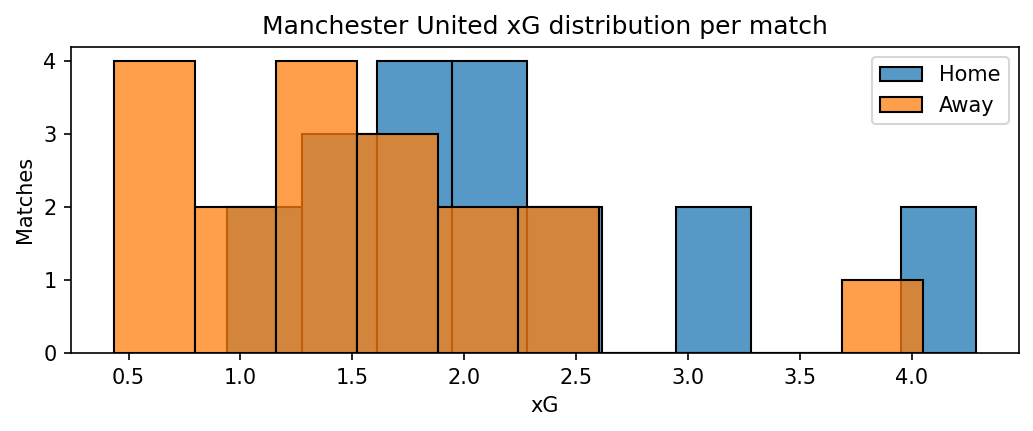

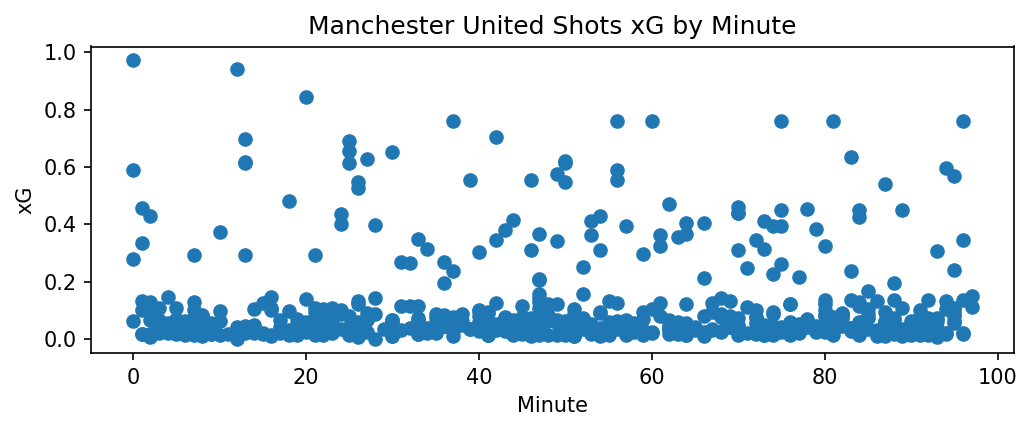

In [35]:
# Save the EDA plots
display(Image(filename="manchester_united_xg_distribution.png"))
display(Image(filename="manchester_united_shot_xg.png"))

- More EDA scripts to come...